In [1]:
# Cell 1: Environment Setup, Repository Cloning, & Library Imports

!pip install -q sentence-transformers

import os
if not os.path.exists('/content/ESC'):
    os.system('git clone https://github.com/Yiwei98/ESC.git')

os.chdir('/content/ESC')
print(f"Working directory: {os.getcwd()}")

import json
import re
import random
import time
import requests
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer, util
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model_embedder = SentenceTransformer('all-mpnet-base-v2', device=device)
print("Encoder loaded ✅")

Working directory: /content/ESC
Device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoder loaded ✅


In [2]:
# Cell 2: Helper Functions & Text Processing

ANS_RE = re.compile(r"#### (\-?[0-9\.\,]+)")
INVALID_ANS = "[invalid]"

def extract_gold_answer(completion):
    match = ANS_RE.search(completion)
    if match:
        return str(match.group(1).strip().replace(",", ""))
    return INVALID_ANS

def extract_predicted_number(text):
    number_list = re.findall(r"\d+\.?\d*", text)
    try:
        return str(number_list[-1].strip('.'))
    except IndexError:
        return "-1000"

def extract_gold_answer_strategy(answer):
    if isinstance(answer, dict):
        return 'yes' if answer.get('Yes', 0) == 1 else 'no'
    s = str(answer).lower()
    return 'yes' if "'yes': 1" in s or '"yes": 1' in s else 'no'

def extract_predicted_strategy(text):
    text = str(text).lower().strip()
    for sent in reversed(text.split('.')):
        sent = sent.strip()
        if sent.endswith('yes') or ' yes' in sent[-15:] or sent.startswith('yes'):
            return 'yes'
        if sent.endswith('no') or ' no' in sent[-15:] or sent.startswith('no'):
            return 'no'
    if 'yes' in text: return 'yes'
    if 'no'  in text: return 'no'
    return '[invalid]'

def extract_final_answer(text, task_type):
    if task_type == 'gsm8k':
        return extract_predicted_number(text)
    else:
        return extract_predicted_strategy(text)

def calculate_similarity_from_embeddings(all_embeddings, start, end):
    window_emb = all_embeddings[start:end]
    if len(window_emb) <= 1:
        return 1.0
    sim_matrix   = util.cos_sim(window_emb, window_emb).cpu().numpy()
    triu_indices = np.triu_indices_from(sim_matrix, k=1)
    return float(np.mean(sim_matrix[triu_indices]))



from collections import Counter

# ── DETERMINISTIC MAJORITY VOTE ───────────────────────────────────────────────
# Replaces:  max(set(preds), key=preds.count)
# That version broke ties using set iteration order, which depends on
# PYTHONHASHSEED and therefore changes between sessions.
# This version breaks ties lexicographically — stable across sessions/platforms.
def majority_vote(preds):
    counts = Counter(preds)
    return sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]

# self-test
assert majority_vote(['yes']*20 + ['no']*20) == 'no'
assert majority_vote(['yes']*28 + ['no']*12) == 'yes'
print("Deterministic vote ready ✅")

Deterministic vote ready ✅


In [3]:
import shutil, os
from google.colab import drive
drive.mount('/content/drive')

os.makedirs("/content/ESC/GPT-OSS-20B_result/gsm8k",   exist_ok=True)
os.makedirs("/content/ESC/GPT-OSS-20B_result/strategy", exist_ok=True)

shutil.copy("/content/drive/MyDrive/GPT-OSS-20B_result/gsm8k/T0.7.jsonl",
            "/content/ESC/GPT-OSS-20B_result/gsm8k/T0.7.jsonl")

shutil.copy("/content/drive/MyDrive/GPT-OSS-20B_result/strategy/T0.7.jsonl",
            "/content/ESC/GPT-OSS-20B_result/strategy/T0.7.jsonl")

print("✅ Files restored!")

Mounted at /content/drive
✅ Files restored!


In [4]:
import os

for model in ["GPT3.5", "GPT4", "GPT-OSS-20B"]:
    for task in ["gsm8k", "strategy"]:
        path = f"{model}_result/{task}/T0.7.jsonl"
        exists = os.path.exists(path)
        print(f"{path} → {'✅ Found' if exists else '❌ Not Found'}")

GPT3.5_result/gsm8k/T0.7.jsonl → ✅ Found
GPT3.5_result/strategy/T0.7.jsonl → ✅ Found
GPT4_result/gsm8k/T0.7.jsonl → ✅ Found
GPT4_result/strategy/T0.7.jsonl → ✅ Found
GPT-OSS-20B_result/gsm8k/T0.7.jsonl → ✅ Found
GPT-OSS-20B_result/strategy/T0.7.jsonl → ✅ Found


In [5]:
# Cell 3: Configuration, Data Loading, and Main Simulation Loop
import time

WINDOW_SIZE   = 5
MAX_SAMPLES   = 40
THRESHOLDS    = [0.50, 0.85, 0.95]
MODELS_TO_RUN = ["GPT3.5", "GPT4", "GPT-OSS-20B"]
TASKS_TO_RUN  = ["gsm8k", "strategy"]

simulation_results = []
total_start = time.time()

for TASK_TYPE in TASKS_TO_RUN:
    for MODEL_TYPE in MODELS_TO_RUN:

        FILE_PATH = f"{MODEL_TYPE}_result/{TASK_TYPE}/T0.7.jsonl"
        print(f"\n{'='*60}\nRunning: {MODEL_TYPE} / {TASK_TYPE}\n{'='*60}")

        try:
            with open(FILE_PATH, "r", encoding="utf-8") as f:
                data = f.readlines()
            print(f"Loaded {len(data)} questions.")
        except FileNotFoundError:
            print(f"File not found: {FILE_PATH} — Skipping!")
            continue

        run_start = time.time()
        random.seed(0)

        for q_idx, line in enumerate(tqdm(data, desc=f"{MODEL_TYPE} | {TASK_TYPE}")):

            tem      = json.loads(line)
            gold_ans = extract_gold_answer(tem['answer']) if TASK_TYPE == 'gsm8k' else extract_gold_answer_strategy(tem['answer'])

            shu_batch = tem['generated_answer'][:MAX_SAMPLES]
            random.shuffle(shu_batch)

            total_tokens_all_paths = sum(len(t.split()) for t in shu_batch)
            all_embeddings         = model_embedder.encode(shu_batch, convert_to_tensor=True)

            baseline_stop_window  = MAX_SAMPLES
            baseline_tokens_saved = 0
            baseline_stopped      = False

            semantic_stop_windows = {t: MAX_SAMPLES for t in THRESHOLDS}
            semantic_tokens_saved = {t: 0           for t in THRESHOLDS}
            active_thresholds     = list(THRESHOLDS)

            for w_idx in range(MAX_SAMPLES // WINDOW_SIZE):
                current_samples_count = (w_idx + 1) * WINDOW_SIZE
                current_window_texts  = shu_batch[w_idx * WINDOW_SIZE : current_samples_count]
                tokens_spent          = sum(len(t.split()) for t in shu_batch[:current_samples_count])
                current_saved_tokens  = max(0, total_tokens_all_paths - tokens_spent)

                if not baseline_stopped:
                    window_preds = [extract_final_answer(t, TASK_TYPE) for t in current_window_texts]
                    if len(set(window_preds)) == 1:
                        baseline_stop_window  = current_samples_count
                        baseline_tokens_saved = current_saved_tokens
                        baseline_stopped      = True

                if active_thresholds:
                    semantic_sim = calculate_similarity_from_embeddings(
                        all_embeddings, w_idx * WINDOW_SIZE, current_samples_count
                    )
                    for t in list(active_thresholds):
                        if semantic_sim >= t:
                            semantic_stop_windows[t] = current_samples_count
                            semantic_tokens_saved[t] = current_saved_tokens
                            active_thresholds.remove(t)

                if baseline_stopped and not active_thresholds:
                    break

            # ── FIX 1 ─────────────────────────────────────────────────────────
            full_preds    = [extract_final_answer(t, TASK_TYPE) for t in shu_batch]
            full_majority = majority_vote(full_preds)

            # ── FIX 2 ─────────────────────────────────────────────────────────
            bl_preds    = [extract_final_answer(t, TASK_TYPE) for t in shu_batch[:baseline_stop_window]]
            bl_majority = majority_vote(bl_preds)

            # ── FIX 3 ─────────────────────────────────────────────────────────
            semantic_majorities = {}
            for t in THRESHOLDS:
                stop_w  = semantic_stop_windows[t]
                preds   = [extract_final_answer(x, TASK_TYPE) for x in shu_batch[:stop_w]]
                semantic_majorities[t] = majority_vote(preds)

            simulation_results.append({
                'model_type':            MODEL_TYPE,
                'task_type':             TASK_TYPE,
                'question_idx':          q_idx,
                'gold_answer':           gold_ans,
                'baseline_stop_window':  baseline_stop_window,
                'baseline_tokens_saved': baseline_tokens_saved,
                'stop_window_0.50':      semantic_stop_windows[0.50],
                'stop_window_0.85':      semantic_stop_windows[0.85],
                'stop_window_0.95':      semantic_stop_windows[0.95],
                'tokens_saved_0.50':     semantic_tokens_saved[0.50],
                'tokens_saved_0.85':     semantic_tokens_saved[0.85],
                'tokens_saved_0.95':     semantic_tokens_saved[0.95],
                'is_correct_full':       (full_majority              == gold_ans),
                'is_correct_baseline':   (bl_majority                == gold_ans),
                'is_correct_0.50':       (semantic_majorities[0.50]  == gold_ans),
                'is_correct_0.85':       (semantic_majorities[0.85]  == gold_ans),
                'is_correct_0.95':       (semantic_majorities[0.95]  == gold_ans),
            })

        print(f"Done in {(time.time()-run_start)/60:.2f} min")

print(f"\nTotal time: {(time.time()-total_start)/60:.2f} min")

# ── Save results to Drive (NEW filename — keeps the old file intact) ──────────
import pandas as pd
df_results = pd.DataFrame(simulation_results)
df_results.to_csv("/content/drive/MyDrive/simulation_results_fixed.csv", index=False)
print(f"✅ Results saved to Drive as simulation_results_fixed.csv ({len(df_results)} rows)")


Running: GPT3.5 / gsm8k
Loaded 1318 questions.


GPT3.5 | gsm8k:   0%|          | 0/1318 [00:00<?, ?it/s]

Done in 8.76 min

Running: GPT4 / gsm8k
Loaded 1319 questions.


GPT4 | gsm8k:   0%|          | 0/1319 [00:00<?, ?it/s]

Done in 6.78 min

Running: GPT-OSS-20B / gsm8k
Loaded 200 questions.


...

Done in 7.69 min

Running: GPT4 / strategy
Loaded 2290 questions.


GPT4 | strategy:   0%|          | 0/2290 [00:00<?, ?it/s]

Done in 7.05 min

Running: GPT-OSS-20B / strategy
Loaded 200 questions.


GPT-OSS-20B | strategy:   0%|          | 0/200 [00:00<?, ?it/s]

Done in 1.18 min

Total time: 32.49 min
✅ Results saved to Drive as simulation_results_fixed.csv (7608 rows)


In [6]:
# Cell 4: Exporting Raw Results & Generating the Main Results Table

df_results = pd.DataFrame(simulation_results)

# ── Save to Drive with a new filename (keeps the old file intact) ─────────────
df_results.to_csv("/content/drive/MyDrive/all_models_semantic_evaluation_fixed.csv", index=False)
print(f"Raw results saved.\n")

print("--- MAIN RESULTS TABLE (Efficiency, Cost Savings & Accuracy) ---")

for task in df_results['task_type'].unique():
    for model in df_results['model_type'].unique():

        df_model = df_results[
            (df_results['model_type'] == model) &
            (df_results['task_type']  == task)
        ]

        if df_model.empty:
            continue

        print(f"\n{'='*65}")
        print(f"  Model: {model} / {task}  |  Questions: {df_model['question_idx'].nunique()}")
        print(f"{'='*65}")

        summary_data = []

        avg_samples_baseline = df_model['baseline_stop_window'].mean()
        saved_cost_baseline  = ((MAX_SAMPLES - avg_samples_baseline) / MAX_SAMPLES) * 100

        summary_data.append({
            'Method':             'Standard SC (No Early Stop)',
            'Avg. Samples':       float(MAX_SAMPLES),
            'Avg. Tokens Saved':  0.0,
            'Saved Cost (%)':     "0.00%",
            'Accuracy (%)':       f"{df_model['is_correct_full'].mean()*100:.2f}%"
        })

        summary_data.append({
            'Method':             'ESC Baseline (Exact Match)',
            'Avg. Samples':       round(avg_samples_baseline, 2),
            'Avg. Tokens Saved':  round(df_model['baseline_tokens_saved'].mean(), 2),
            'Saved Cost (%)':     f"{saved_cost_baseline:.2f}%",
            'Accuracy (%)':       f"{df_model['is_correct_baseline'].mean()*100:.2f}%"
        })

        for t in THRESHOLDS:
            avg_samples = df_model[f'stop_window_{t:.2f}'].mean()
            avg_tokens  = df_model[f'tokens_saved_{t:.2f}'].mean()
            saved_cost  = ((MAX_SAMPLES - avg_samples) / MAX_SAMPLES) * 100

            summary_data.append({
                'Method':             f'Ours (Semantic τ={t:.2f})',
                'Avg. Samples':       round(avg_samples, 2),
                'Avg. Tokens Saved':  round(avg_tokens, 2),
                'Saved Cost (%)':     f"{saved_cost:.2f}%",
                'Accuracy (%)':       f"{df_model[f'is_correct_{t:.2f}'].mean()*100:.2f}%"
            })

        print(pd.DataFrame(summary_data).to_string(index=False))

print("\nResults table complete!")

Raw results saved.

--- MAIN RESULTS TABLE (Efficiency, Cost Savings & Accuracy) ---

  Model: GPT3.5 / gsm8k  |  Questions: 1318
                     Method  Avg. Samples  Avg. Tokens Saved Saved Cost (%) Accuracy (%)
Standard SC (No Early Stop)         40.00               0.00          0.00%       85.66%
 ESC Baseline (Exact Match)         14.59            1730.06         63.51%       85.66%
     Ours (Semantic τ=0.50)          5.00            2605.47         87.50%       82.09%
     Ours (Semantic τ=0.85)          5.11            2598.80         87.22%       82.09%
     Ours (Semantic τ=0.95)         15.45            1747.82         61.37%       84.75%

  Model: GPT4 / gsm8k  |  Questions: 1319
                     Method  Avg. Samples  Avg. Tokens Saved Saved Cost (%) Accuracy (%)
Standard SC (No Early Stop)         40.00               0.00          0.00%       89.31%
 ESC Baseline (Exact Match)          8.04            2099.39         79.90%       89.31%
     Ours (Semantic τ=0.50

In [7]:
# ── Ablation Study — fixed vote, embeddings cached, only needed configs ───────
import json, random, time
import pandas as pd
from tqdm.notebook import tqdm

ABL_TAU = 0.85
CONFIGS = [(40, 2), (40, 5), (40, 10), (20, 5)]   # (40,5) kept as a consistency check

ablation_rows = []
t0 = time.time()

for TASK_TYPE in TASKS_TO_RUN:
    for MODEL_TYPE in MODELS_TO_RUN:

        FILE_PATH = f"{MODEL_TYPE}_result/{TASK_TYPE}/T0.7.jsonl"
        try:
            with open(FILE_PATH, "r", encoding="utf-8") as f:
                data = f.readlines()
        except FileNotFoundError:
            print(f"File not found: {FILE_PATH} — Skipping!")
            continue

        print(f"\n{'='*60}\n{MODEL_TYPE} / {TASK_TYPE}  ({len(data)} questions)\n{'='*60}")

        # encode ONCE per question — reused by every configuration below
        cache = []
        for line in tqdm(data, desc="encoding"):
            tem   = json.loads(line)
            gold  = extract_gold_answer(tem['answer']) if TASK_TYPE == 'gsm8k' \
                    else extract_gold_answer_strategy(tem['answer'])
            paths = tem['generated_answer'][:40]
            emb   = model_embedder.encode(paths, convert_to_tensor=True).cpu()
            cache.append((paths, gold, emb))

        for (MAXS, WSIZE) in CONFIGS:
            random.seed(0)
            correct_ours = correct_sc = samples_ours = 0

            for paths, gold, emb_all in cache:
                idx = list(range(min(MAXS, len(paths))))
                random.shuffle(idx)
                shu_batch = [paths[i] for i in idx]
                emb       = emb_all[idx]
                n         = len(shu_batch)

                stop_w = n
                for w_idx in range(n // WSIZE):
                    cur = (w_idx + 1) * WSIZE
                    if calculate_similarity_from_embeddings(emb, w_idx * WSIZE, cur) >= ABL_TAU:
                        stop_w = cur
                        break

                samples_ours += stop_w
                preds = [extract_final_answer(t, TASK_TYPE) for t in shu_batch]
                if majority_vote(preds) == gold:
                    correct_sc += 1
                if majority_vote(preds[:stop_w]) == gold:
                    correct_ours += 1

            nq  = len(cache)
            avg = samples_ours / nq
            ablation_rows.append({
                'Model': MODEL_TYPE, 'Task': TASK_TYPE,
                'Max Samples Limit': MAXS, 'Window Size': WSIZE,
                'Ours Avg Samples': round(avg, 2),
                'Ours Saved Cost (%)': round((MAXS - avg) / MAXS * 100, 2),
                'Ours Accuracy (%)': round(correct_ours / nq * 100, 2),
                'Standard SC Accuracy (%)': round(correct_sc / nq * 100, 2),
            })
            r = ablation_rows[-1]
            print(f"  L={MAXS:2d} w={WSIZE:2d}  →  ours {r['Ours Accuracy (%)']:.2f}  "
                  f"| SC {r['Standard SC Accuracy (%)']:.2f}  | avg {avg:.2f}")

        del cache

df_ablation = pd.DataFrame(ablation_rows)
df_ablation.to_csv("/content/drive/MyDrive/ablation_results_fixed.csv", index=False)
print(f"\nTotal: {(time.time()-t0)/60:.2f} min")
print(df_ablation.to_string(index=False))


GPT3.5 / gsm8k  (1318 questions)


encoding:   0%|          | 0/1318 [00:00<?, ?it/s]

  L=40 w= 2  →  ours 77.09  | SC 85.66  | avg 2.10
  L=40 w= 5  →  ours 82.09  | SC 85.66  | avg 5.11
  L=40 w=10  →  ours 84.52  | SC 85.66  | avg 10.17
  L=20 w= 5  →  ours 81.94  | SC 85.36  | avg 5.09

GPT4 / gsm8k  (1319 questions)


encoding:   0%|          | 0/1319 [00:00<?, ?it/s]

  L=40 w= 2  →  ours 88.78  | SC 89.31  | avg 2.09
  L=40 w= 5  →  ours 89.61  | SC 89.31  | avg 5.09
  L=40 w=10  →  ours 89.61  | SC 89.31  | avg 10.08
  L=20 w= 5  →  ours 88.32  | SC 89.08  | avg 5.13

GPT-OSS-20B / gsm8k  (200 questions)


...

  L=40 w= 2  →  ours 71.46  | SC 74.66  | avg 2.29
  L=40 w= 5  →  ours 74.48  | SC 74.66  | avg 5.64
  L=40 w=10  →  ours 74.44  | SC 74.66  | avg 10.84
  L=20 w= 5  →  ours 74.79  | SC 74.40  | avg 5.38

GPT4 / strategy  (2290 questions)


encoding:   0%|          | 0/2290 [00:00<?, ?it/s]

  L=40 w= 2  →  ours 80.92  | SC 81.53  | avg 2.19
  L=40 w= 5  →  ours 81.70  | SC 81.53  | avg 5.43
  L=40 w=10  →  ours 81.53  | SC 81.53  | avg 10.59
  L=20 w= 5  →  ours 81.27  | SC 81.35  | avg 5.32

GPT-OSS-20B / strategy  (200 questions)


encoding:   0%|          | 0/200 [00:00<?, ?it/s]

  L=40 w= 2  →  ours 69.50  | SC 72.50  | avg 6.09
  L=40 w= 5  →  ours 71.00  | SC 72.50  | avg 24.70
  L=40 w=10  →  ours 72.50  | SC 72.50  | avg 33.15
  L=20 w= 5  →  ours 70.50  | SC 71.50  | avg 15.40

Total: 32.70 min
      Model     Task  Max Samples Limit  Window Size  Ours Avg Samples  Ours Saved Cost (%)  Ours Accuracy (%)  Standard SC Accuracy (%)
     GPT3.5    gsm8k                 40            2              2.10                94.75              77.09                     85.66
     GPT3.5    gsm8k                 40            5              5.11                87.22              82.09                     85.66
     GPT3.5    gsm8k                 40           10             10.17                74.56              84.52                     85.66
     GPT3.5    gsm8k                 20            5              5.09                74.54              81.94                     85.36
       GPT4    gsm8k                 40            2              2.09                94.7

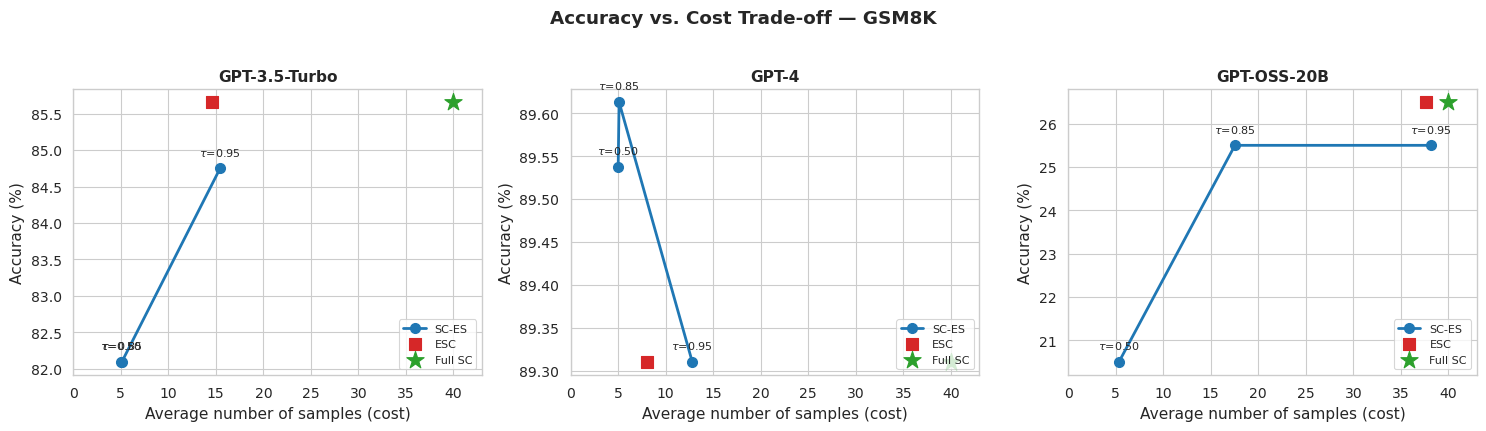

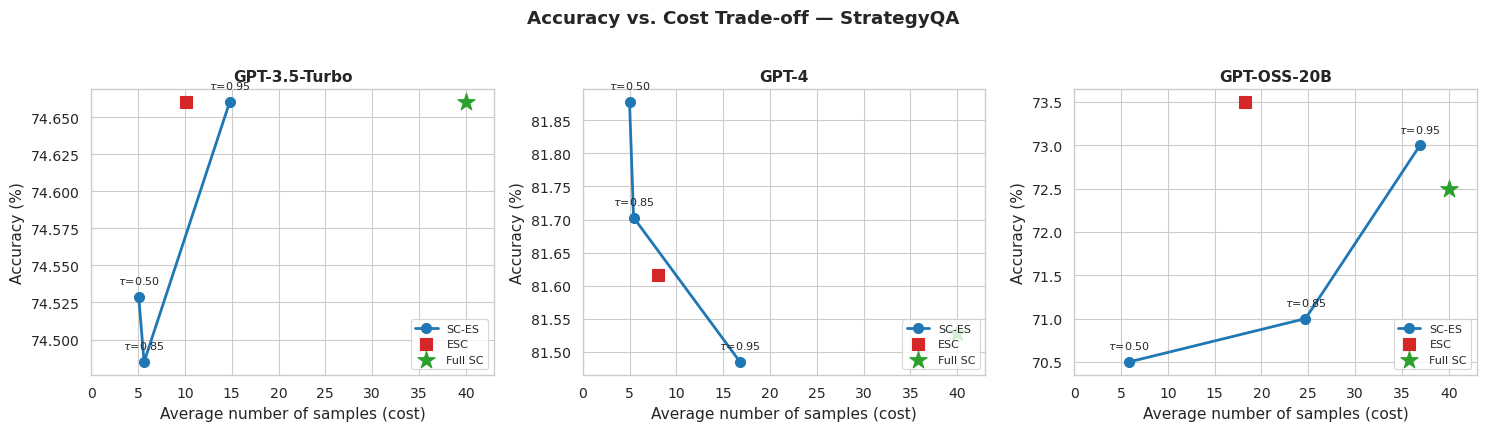

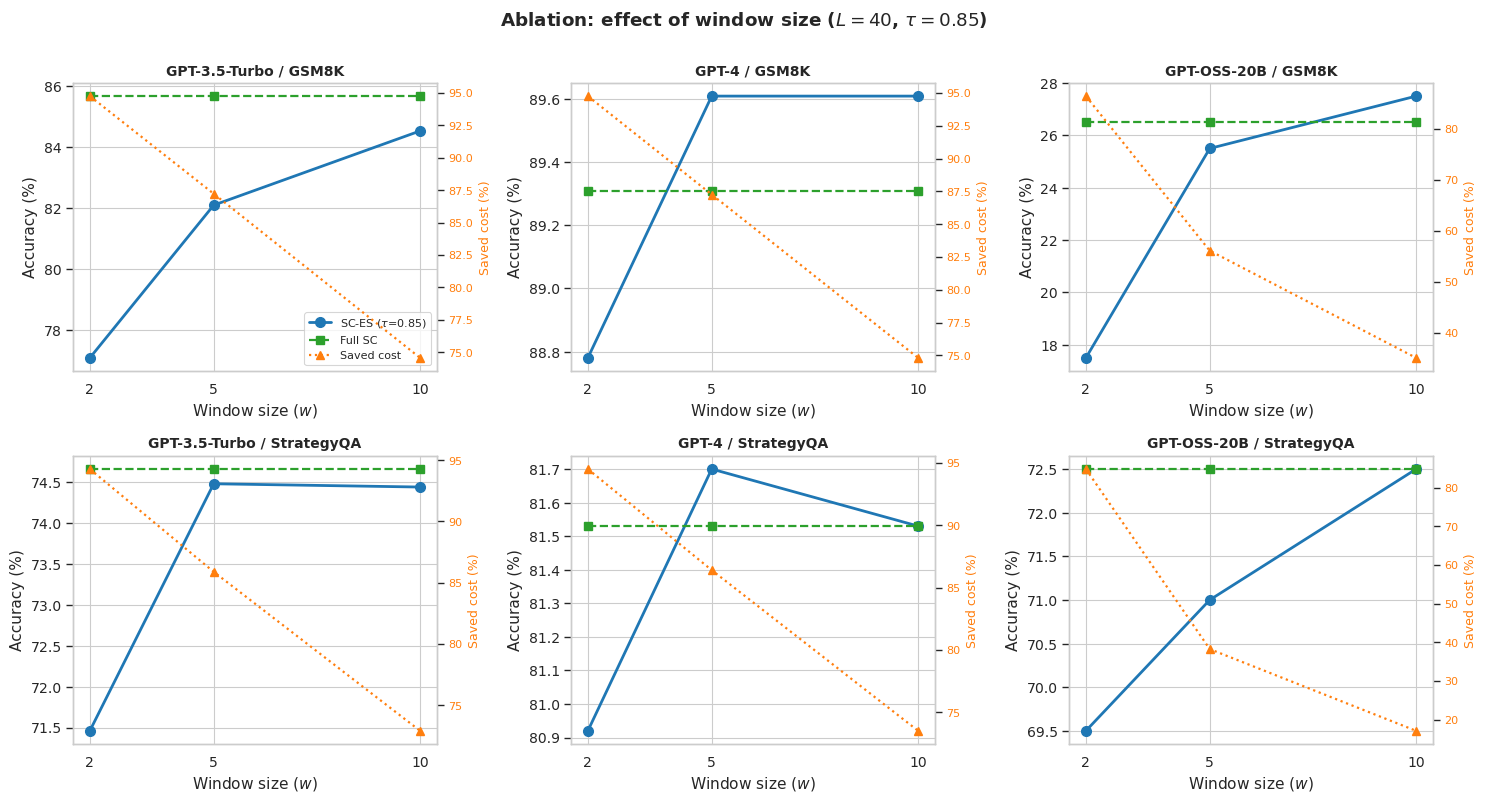

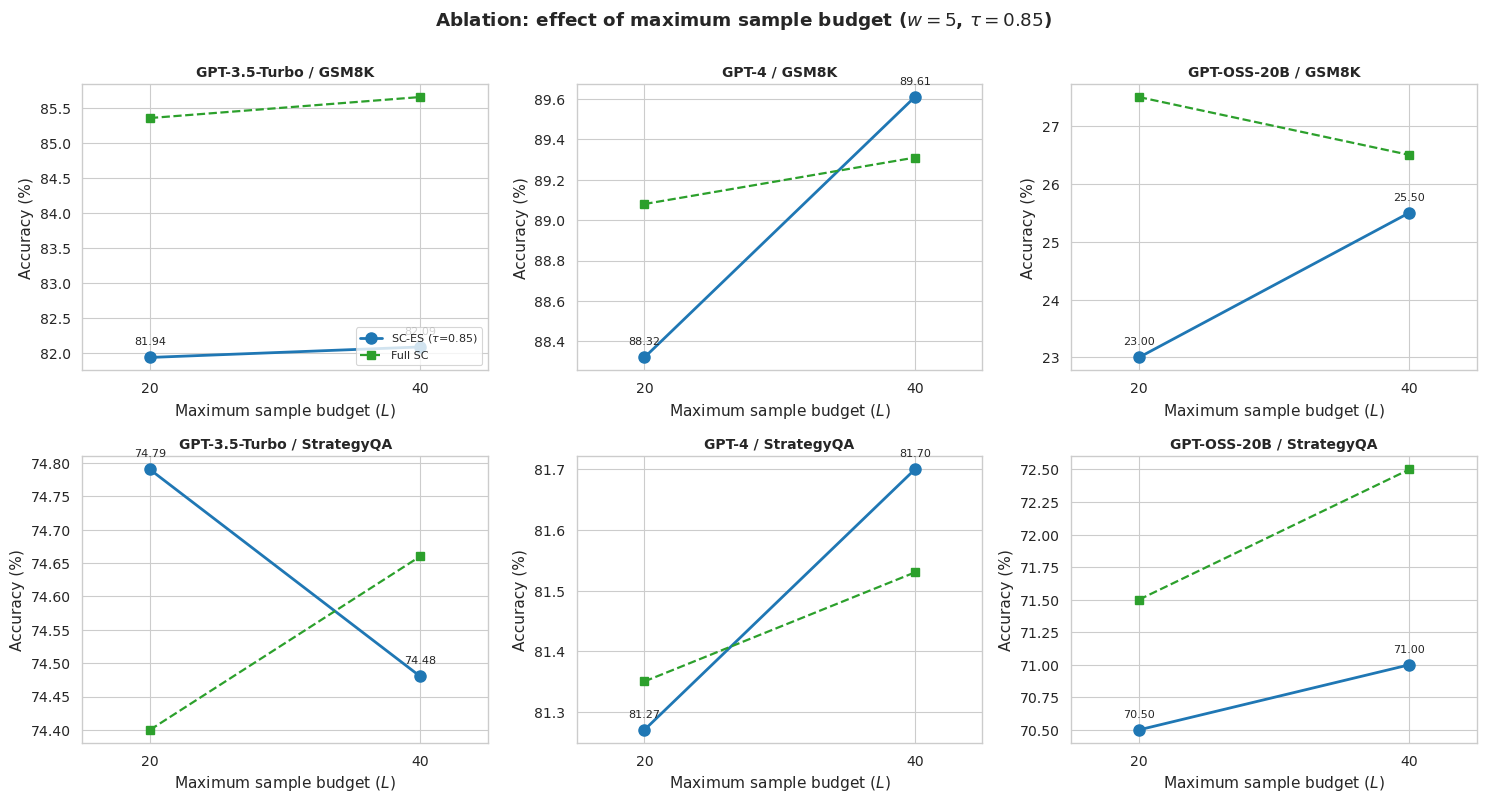

All figures saved to: /content/drive/MyDrive/figures_fixed


In [8]:
# ── Regenerate all data-driven figures from the corrected results ─────────────
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)

OUTDIR = "/content/drive/MyDrive/figures_fixed"
os.makedirs(OUTDIR, exist_ok=True)

# If the session restarted, reload from Drive instead of re-running:
# df_results  = pd.read_csv("/content/drive/MyDrive/simulation_results_fixed.csv")
# df_ablation = pd.read_csv("/content/drive/MyDrive/ablation_results_fixed.csv")

MODEL_LABEL = {"GPT3.5": "GPT-3.5-Turbo", "GPT4": "GPT-4", "GPT-OSS-20B": "GPT-OSS-20B"}
TASK_LABEL  = {"gsm8k": "GSM8K", "strategy": "StrategyQA"}
MODELS      = ["GPT3.5", "GPT4", "GPT-OSS-20B"]

# ═══ FIGURE A: accuracy-cost trade-off (one figure per dataset) ═══════════════
for task in ["gsm8k", "strategy"]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, model in zip(axes, MODELS):
        d = df_results[(df_results.model_type == model) & (df_results.task_type == task)]
        if d.empty:
            ax.axis("off"); continue

        xs = [d[f"stop_window_{t:.2f}"].mean() for t in THRESHOLDS]
        ys = [d[f"is_correct_{t:.2f}"].mean() * 100 for t in THRESHOLDS]

        ax.plot(xs, ys, "o-", color="#1f77b4", lw=2, ms=7, label="SC-ES", zorder=3)
        for x, y, t in zip(xs, ys, THRESHOLDS):
            ax.annotate(f"$\\tau$={t:.2f}", (x, y), textcoords="offset points",
                        xytext=(0, 9), ha="center", fontsize=8)

        ax.scatter(d.baseline_stop_window.mean(), d.is_correct_baseline.mean() * 100,
                   marker="s", s=70, color="#d62728", label="ESC", zorder=4)
        ax.scatter(MAX_SAMPLES, d.is_correct_full.mean() * 100,
                   marker="*", s=170, color="#2ca02c", label="Full SC", zorder=4)

        ax.set_title(MODEL_LABEL[model], fontweight="bold")
        ax.set_xlabel("Average number of samples (cost)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xlim(0, MAX_SAMPLES + 3)
        ax.legend(frameon=True, fontsize=8, loc="lower right")

    fig.suptitle(f"Accuracy vs. Cost Trade-off — {TASK_LABEL[task]}", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/tradeoff_{task}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ═══ FIGURE B: ablation — window size (L=40) ══════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, task in enumerate(["gsm8k", "strategy"]):
    for c, model in enumerate(MODELS):
        ax = axes[r, c]
        d = df_ablation[(df_ablation.Model == model) & (df_ablation.Task == task) &
                        (df_ablation["Max Samples Limit"] == 40)].sort_values("Window Size")
        if d.empty:
            ax.axis("off"); continue

        ax.plot(d["Window Size"], d["Ours Accuracy (%)"], "o-",
                color="#1f77b4", lw=2, ms=7, label="SC-ES ($\\tau$=0.85)")
        ax.plot(d["Window Size"], d["Standard SC Accuracy (%)"], "s--",
                color="#2ca02c", lw=1.6, ms=6, label="Full SC")

        ax2 = ax.twinx()
        ax2.plot(d["Window Size"], d["Ours Saved Cost (%)"], "^:",
                 color="#ff7f0e", lw=1.6, ms=6, label="Saved cost")
        ax2.set_ylabel("Saved cost (%)", color="#ff7f0e", fontsize=9)
        ax2.tick_params(axis="y", labelcolor="#ff7f0e", labelsize=8)
        ax2.grid(False)

        ax.set_title(f"{MODEL_LABEL[model]} / {TASK_LABEL[task]}", fontweight="bold", fontsize=10)
        ax.set_xlabel("Window size ($w$)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xticks([2, 5, 10])
        if r == 0 and c == 0:
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="lower right")

fig.suptitle("Ablation: effect of window size ($L=40$, $\\tau=0.85$)", fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/ablation_window.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══ FIGURE C: ablation — sample budget (w=5) ═════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, task in enumerate(["gsm8k", "strategy"]):
    for c, model in enumerate(MODELS):
        ax = axes[r, c]
        d = df_ablation[(df_ablation.Model == model) & (df_ablation.Task == task) &
                        (df_ablation["Window Size"] == 5)].sort_values("Max Samples Limit")
        if d.empty:
            ax.axis("off"); continue

        ax.plot(d["Max Samples Limit"], d["Ours Accuracy (%)"], "o-",
                color="#1f77b4", lw=2, ms=8, label="SC-ES ($\\tau$=0.85)")
        ax.plot(d["Max Samples Limit"], d["Standard SC Accuracy (%)"], "s--",
                color="#2ca02c", lw=1.6, ms=6, label="Full SC")
        for x, y in zip(d["Max Samples Limit"], d["Ours Accuracy (%)"]):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                        xytext=(0, 9), ha="center", fontsize=8)

        ax.set_title(f"{MODEL_LABEL[model]} / {TASK_LABEL[task]}", fontweight="bold", fontsize=10)
        ax.set_xlabel("Maximum sample budget ($L$)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xticks([20, 40]); ax.set_xlim(15, 45)
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Ablation: effect of maximum sample budget ($w=5$, $\\tau=0.85$)", fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/ablation_budget.png", dpi=300, bbox_inches="tight")
plt.show()

print("All figures saved to:", OUTDIR)

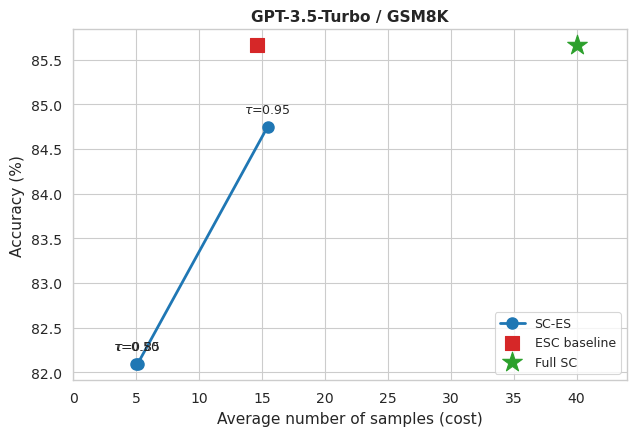

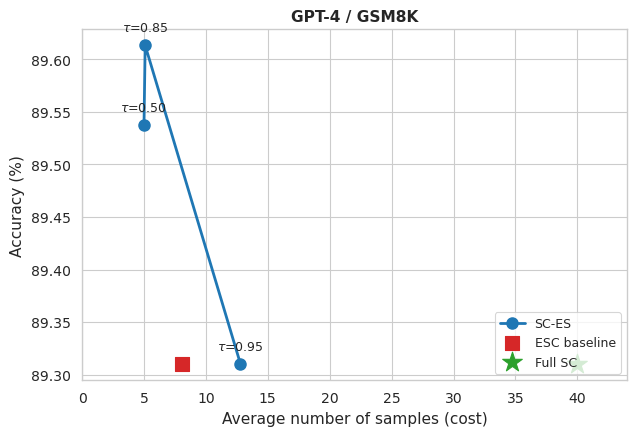

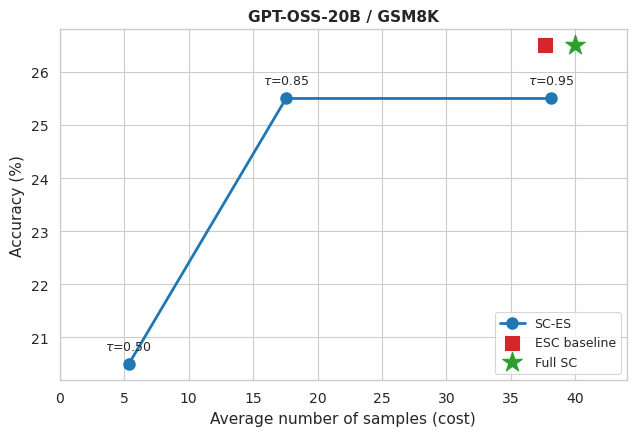

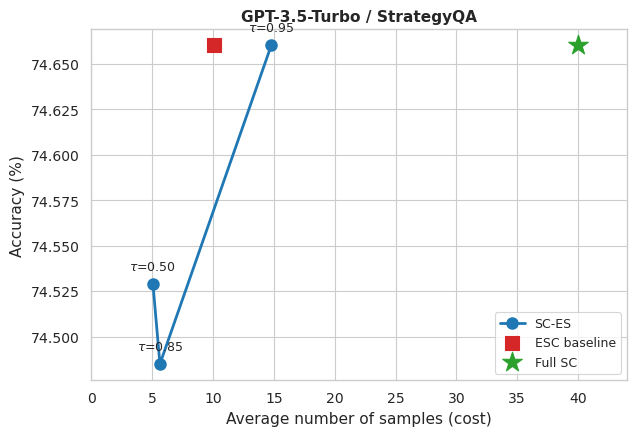

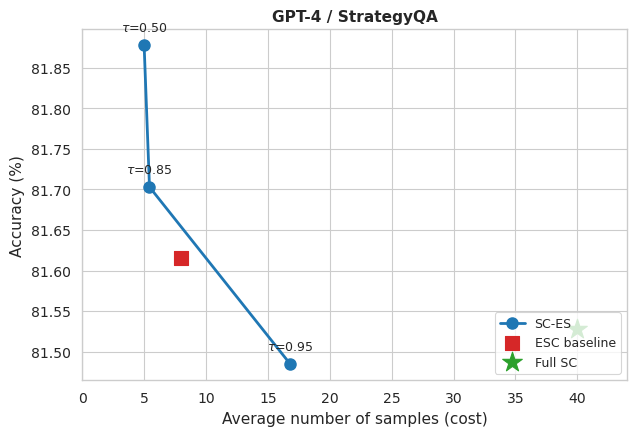

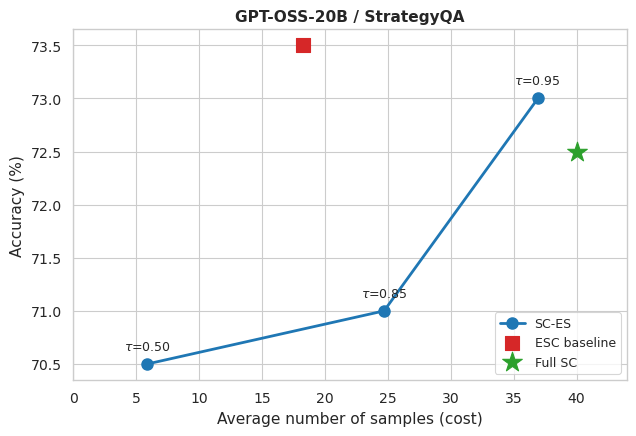

In [9]:
# ═══ FIGURE A: accuracy-cost trade-off — six separate figures ════════════════
for task in ["gsm8k", "strategy"]:
    for model in MODELS:
        d = df_results[(df_results.model_type == model) & (df_results.task_type == task)]
        if d.empty:
            continue

        xs = [d[f"stop_window_{t:.2f}"].mean() for t in THRESHOLDS]
        ys = [d[f"is_correct_{t:.2f}"].mean() * 100 for t in THRESHOLDS]

        fig, ax = plt.subplots(figsize=(6.5, 4.5))
        ax.plot(xs, ys, "o-", color="#1f77b4", lw=2, ms=8, label="SC-ES", zorder=3)
        for x, y, t in zip(xs, ys, THRESHOLDS):
            ax.annotate(f"$\\tau$={t:.2f}", (x, y), textcoords="offset points",
                        xytext=(0, 10), ha="center", fontsize=9)

        ax.scatter(d.baseline_stop_window.mean(), d.is_correct_baseline.mean() * 100,
                   marker="s", s=90, color="#d62728", label="ESC baseline", zorder=4)
        ax.scatter(MAX_SAMPLES, d.is_correct_full.mean() * 100,
                   marker="*", s=220, color="#2ca02c", label="Full SC", zorder=4)

        ax.set_title(f"{MODEL_LABEL[model]} / {TASK_LABEL[task]}", fontweight="bold")
        ax.set_xlabel("Average number of samples (cost)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xlim(0, MAX_SAMPLES + 4)
        ax.legend(frameon=True, fontsize=9, loc="lower right")
        plt.tight_layout()
        plt.savefig(f"{OUTDIR}/tradeoff_{model}_{task}.png", dpi=300, bbox_inches="tight")
        plt.show()

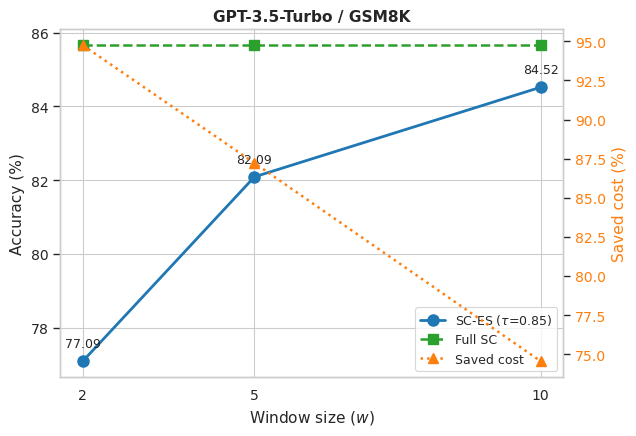

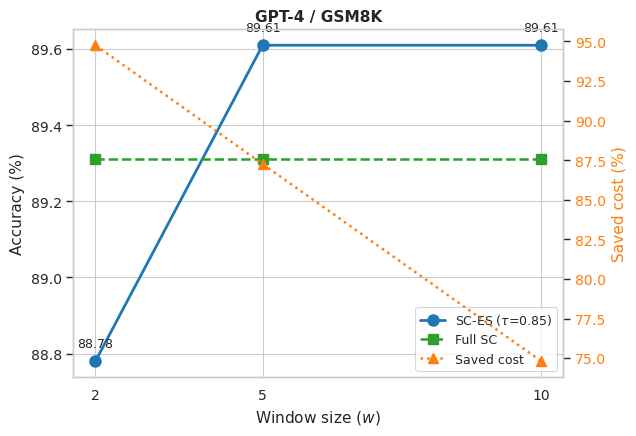

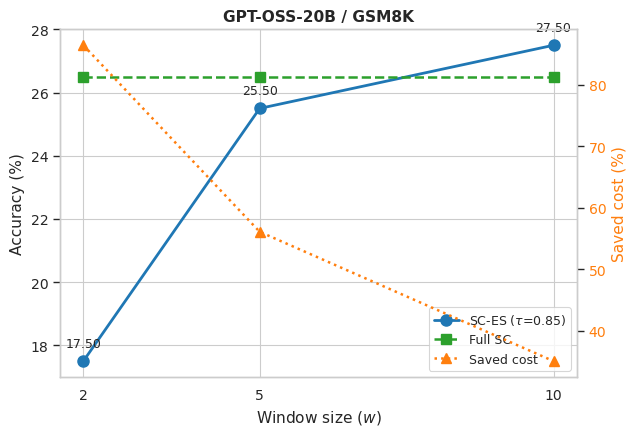

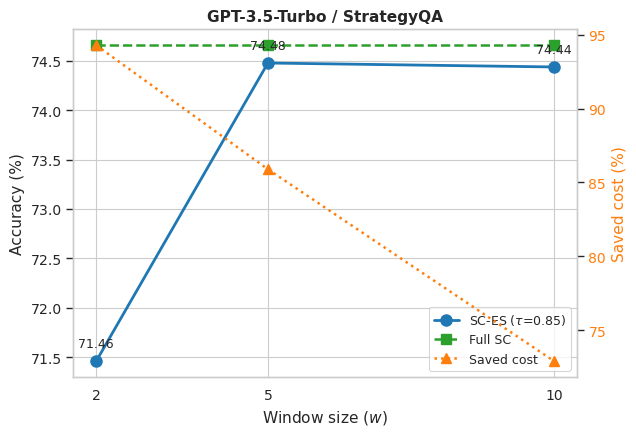

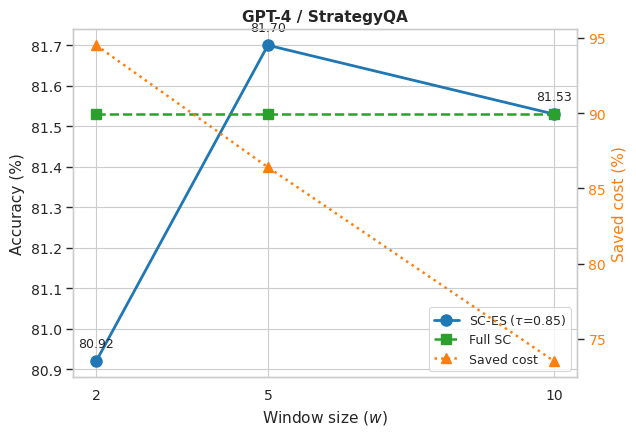

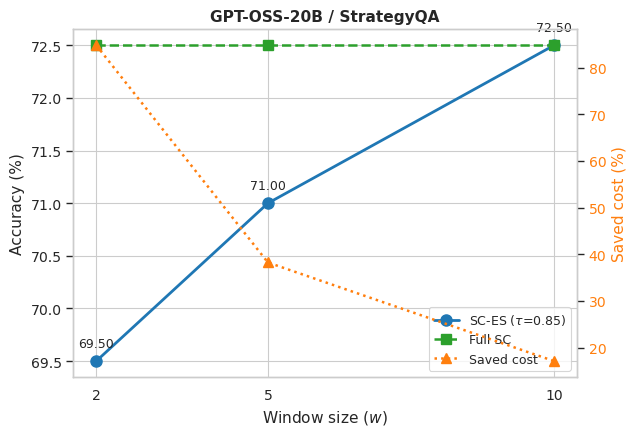

In [10]:
# ═══ FIGURE B: ablation — window size (L=40), six separate figures ═══════════
for task in ["gsm8k", "strategy"]:
    for model in MODELS:
        d = df_ablation[(df_ablation.Model == model) & (df_ablation.Task == task) &
                        (df_ablation["Max Samples Limit"] == 40)].sort_values("Window Size")
        if d.empty:
            continue

        fig, ax = plt.subplots(figsize=(6.5, 4.5))
        ax.plot(d["Window Size"], d["Ours Accuracy (%)"], "o-",
                color="#1f77b4", lw=2, ms=8, label="SC-ES ($\\tau$=0.85)", zorder=3)
        ax.plot(d["Window Size"], d["Standard SC Accuracy (%)"], "s--",
                color="#2ca02c", lw=1.8, ms=7, label="Full SC", zorder=3)
        for x, y in zip(d["Window Size"], d["Ours Accuracy (%)"]):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                        xytext=(0, 10), ha="center", fontsize=9)

        ax2 = ax.twinx()
        ax2.plot(d["Window Size"], d["Ours Saved Cost (%)"], "^:",
                 color="#ff7f0e", lw=1.8, ms=7, label="Saved cost")
        ax2.set_ylabel("Saved cost (%)", color="#ff7f0e")
        ax2.tick_params(axis="y", labelcolor="#ff7f0e")
        ax2.grid(False)

        ax.set_title(f"{MODEL_LABEL[model]} / {TASK_LABEL[task]}", fontweight="bold")
        ax.set_xlabel("Window size ($w$)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xticks([2, 5, 10])

        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=9, loc="lower right")

        plt.tight_layout()
        plt.savefig(f"{OUTDIR}/ablation_window_{model}_{task}.png", dpi=300, bbox_inches="tight")
        plt.show()

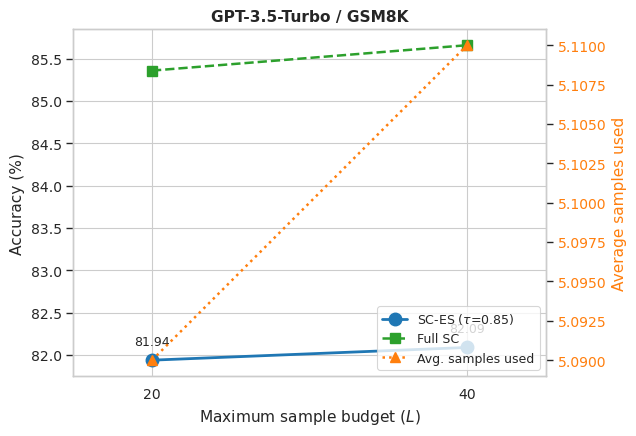

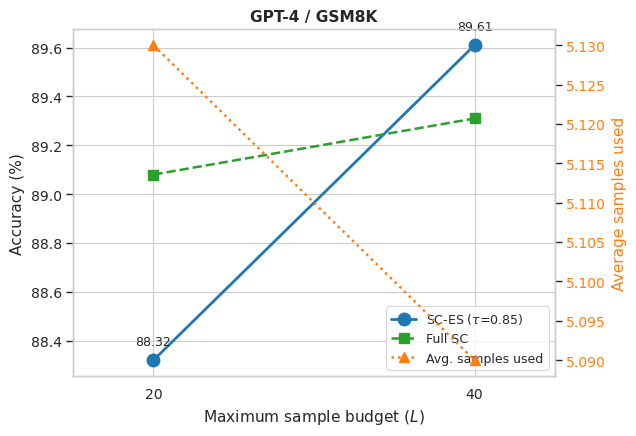

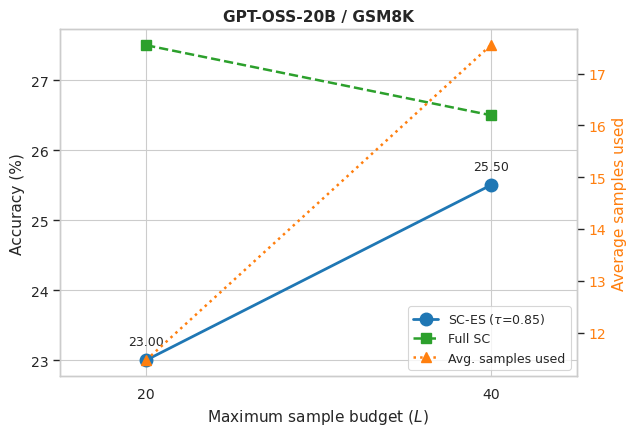

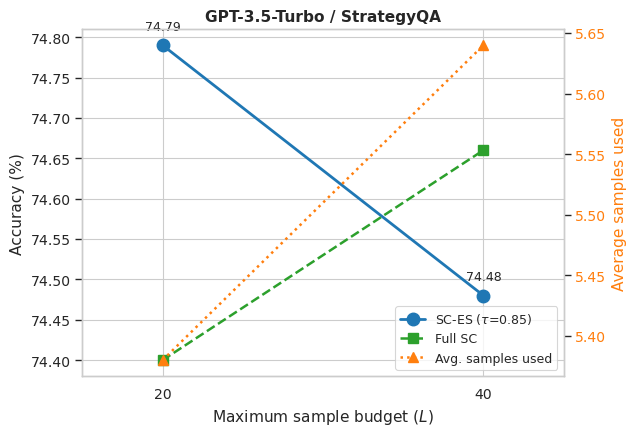

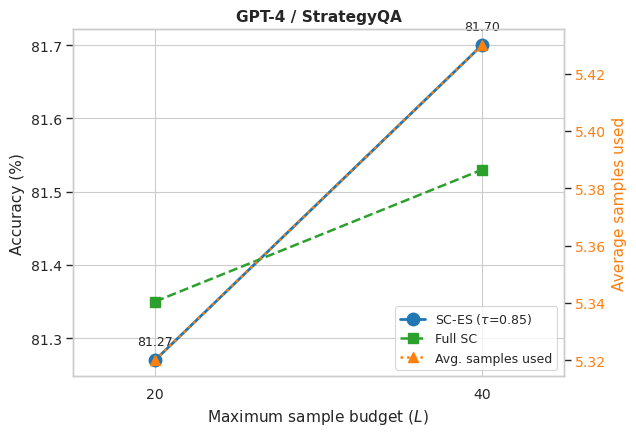

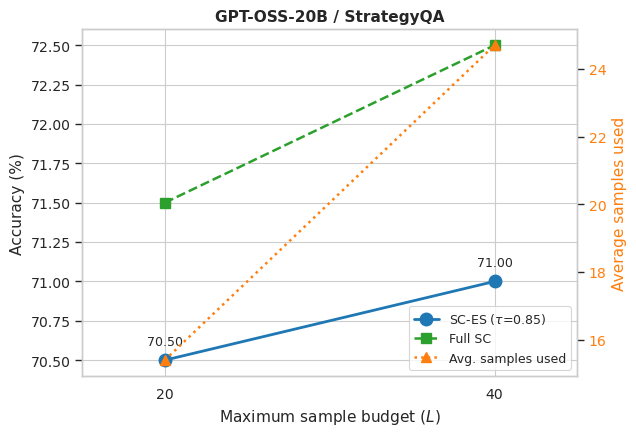

In [11]:
# ═══ FIGURE C: ablation — sample budget (w=5), six separate figures ══════════
for task in ["gsm8k", "strategy"]:
    for model in MODELS:
        d = df_ablation[(df_ablation.Model == model) & (df_ablation.Task == task) &
                        (df_ablation["Window Size"] == 5)].sort_values("Max Samples Limit")
        if d.empty:
            continue

        fig, ax = plt.subplots(figsize=(6.5, 4.5))
        ax.plot(d["Max Samples Limit"], d["Ours Accuracy (%)"], "o-",
                color="#1f77b4", lw=2, ms=9, label="SC-ES ($\\tau$=0.85)", zorder=3)
        ax.plot(d["Max Samples Limit"], d["Standard SC Accuracy (%)"], "s--",
                color="#2ca02c", lw=1.8, ms=7, label="Full SC", zorder=3)
        for x, y in zip(d["Max Samples Limit"], d["Ours Accuracy (%)"]):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                        xytext=(0, 11), ha="center", fontsize=9)

        ax2 = ax.twinx()
        ax2.plot(d["Max Samples Limit"], d["Ours Avg Samples"], "^:",
                 color="#ff7f0e", lw=1.8, ms=7, label="Avg. samples used")
        ax2.set_ylabel("Average samples used", color="#ff7f0e")
        ax2.tick_params(axis="y", labelcolor="#ff7f0e")
        ax2.grid(False)

        ax.set_title(f"{MODEL_LABEL[model]} / {TASK_LABEL[task]}", fontweight="bold")
        ax.set_xlabel("Maximum sample budget ($L$)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_xticks([20, 40]); ax.set_xlim(15, 45)

        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=9, loc="lower right")

        plt.tight_layout()
        plt.savefig(f"{OUTDIR}/ablation_budget_{model}_{task}.png", dpi=300, bbox_inches="tight")
        plt.show()